# 데이터 핸들링-판다스

## 넘파이에 비해 상대적으로 데이터 분석이 편리하다 / 상대적 고성능 API 제공

#### 핀다스의 핵심 객체: Data Frame(여러 개의 행과 열로 이뤄진 2차원 데이터를 담는 ㅔ이터 구조체)
#### -Index: 개별 데이터 고유하게 식별하는 key 값 ,Series와 Data Frame모두 고유 식별 Key가짐
#### -Series: 칼럼이 하나뿐인 데이터 구조 -DataFrame: 칼럼이 여러개인 데이터 구조(DataFrame은 여러개의 Series으로 이루어져 있다.

In [243]:
import pandas as pd

#### 판다스는 read_csv(),read_table(),read_fwf와 같은 편리한 api가 있음
#### -read_csv와 read_table 차이는 구분 문자가 콤마인ㅣ 탭인지의 차이이다,
#### 함수 안에 filepath를 넣어 데이터를 업로드할 수 있다.

In [244]:
titanic_df = pd.read_csv("train.csv")
titanic_df.head(3)

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr....",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mr...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, ...",female,26.0,0,0,STON/O2. 31...,7.9250,NaN,S


In [245]:
titanic_df=pd.read_csv("train.csv")
print("titanic 변수 type:",type(titanic_df))
titanic_df

titanic 변수 type: <class 'pandas.core.frame.DataFrame'>


,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr....",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mr...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, ...",female,26.0,0,0,STON/O2. 31...,7.9250,NaN,S
3,4,1,1,"Futrelle, M...",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. ...",male,35.0,0,0,373450,8.0500,NaN,S
...,...,...,...,...,...,...,...,...,...,...,...,...
886,887,0,2,"Montvila, R...",male,27.0,0,0,211536,13.0000,NaN,S
887,888,1,1,"Graham, Mis...",female,19.0,0,0,112053,30.0000,B42,S
888,889,0,3,"Johnston, M...",female,NaN,1,2,W./C. 6607,23.4500,NaN,S
889,890,1,1,"Behr, Mr. K...",male,26.0,0,0,111369,30.0000,C148,C


#### 모든 DataFrame 내 데이터는 생성되는 순간 고유한 indexf를 가짐

#### DataFrame.head()는 DataFrame() 맨 앞에 있는 N개의 로우 반환

In [246]:
titanic_df.head(3)

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr....",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mr...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, ...",female,26.0,0,0,STON/O2. 31...,7.9250,NaN,S


#### shape로 크기도 알 수 있음-행과 열을 튜플 형태로 반환

In [247]:
print('DataFrame 크기: ',titanic_df.shape)

DataFrame 크기:  (891, 12)


#### info()함수로 데이터 건수와 데이터 타입, NULL 건수를 알 수 있음

In [248]:
titanic_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    object 
 4   Sex          891 non-null    object 
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    object 
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    object 
 11  Embarked     889 non-null    object 
dtypes: float64(2), int64(5), object(5)
memory usage: 83.7+ KB


## describe() 매서드는 칼럼별 숫자형 데이터 값의 n-percentile 분포도, 평균값, 최댓값, 최솟값 나타냄
#### 오직 숫자형 칼럼의 분포도만 조사하고 object 입 컬럼은 출력에세 제외 -> 개략적 분포 파악 가능(정규 분포 이루어지지 않고 왜곡 되면 예측 성능 저하
#### 해당 숫자 칼럼이 숫자형인지 알 수 있게 해줌


In [249]:
titanic_df.describe()

,PassengerId,Survived,Pclass,Age,SibSp,Parch,Fare
count,891.000000,891.000000,891.000000,714.000000,891.000000,891.000000,891.000000
mean,446.000000,0.383838,2.308642,29.699118,0.523008,0.381594,32.204208
std,257.353842,0.486592,0.836071,14.526497,1.102743,0.806057,49.693429
min,1.000000,0.000000,1.000000,0.420000,0.000000,0.000000,0.000000
25%,223.500000,0.000000,2.000000,20.125000,0.000000,0.000000,7.910400
50%,446.000000,0.000000,3.000000,28.000000,0.000000,0.000000,14.454200
75%,668.500000,1.000000,3.000000,38.000000,1.000000,0.000000,31.000000
max,891.000000,1.000000,3.000000,80.000000,8.000000,6.000000,512.329200


##### count: Not Null인 데이터 건수 / mean: 전체 데이터의 평균값 / std: 표준편차 /min&max :최소,최대값 / 나머지 %는 해당 속하는 정도 나타낸 것

### 카테고리 칼럼: 특정 범주에 속하는 값을 숫자화 한 것
##### ex)남자를 1로 여자를 2로 표현

### DataFrame의 []연산자 내부에 칼럼명 넣으면 데이터 값 건수 반환을 함

#### value_counts()는 매서드 호출시 해당 칼럼값의 유형과 건수 확인 가능
#### counts()는 지정된 칼럼의 데이터값 건수를 반환

In [250]:
value_counts=titanic_df["Pclass"].value_counts()
print(value_counts)

Pclass
3    491
1    216
2    184
Name: count, dtype: int64


In [251]:
titanic_pclass=titanic_df['Pclass']
print(type(titanic_pclass)) #시리즈 객체를 반환

<class 'pandas.core.series.Series'>


In [252]:
titanic_pclass.head() #왼쪽이 시리즈 인덱스고 오른쪽이 시리즈 데이터 값

0    3
1    1
2    3
3    1
4    3
Name: Pclass, dtype: int64

In [253]:
value_counts=titanic_df['Pclass'].value_counts()
print(type(value_counts))
print(value_counts)

<class 'pandas.core.series.Series'>
Pclass
3    491
1    216
2    184
Name: count, dtype: int64


#### 인덱스는 이후에도 수정 가능하고 숫자형 뿐만 아니라 문자열도 가능

In [254]:
print('titanic_df 데이터 건수:',titanic_df.shape[0])
print('기본 설정인 dropna=True로 value_counts()')
#vlaue_counts는 기본으로 dropna=True여서 vlaue_counts(dropna=True)와 동일
print(titanic_df['Embarked'].value_counts())
print(titanic_df['Embarked'].value_counts(dropna=False))

titanic_df 데이터 건수: 891
기본 설정인 dropna=True로 value_counts()
Embarked
S    644
C    168
Q     77
Name: count, dtype: int64
Embarked
S      644
C      168
Q       77
NaN      2
Name: count, dtype: int64


## DataFrame과 리스트, 딕셔너리, 넘파이, ndarray 상호 반환

### csv 파일을 read_csv로 DataFrame 생성
#### DataFrame은 리스트, 딕셔너리 등 다양한 데이터로부터 생성 가능 반대로 리스트 딕셔너리 넘파이 ndarray등으로 변환도 가능
#### 따라서 DataFrame과 넘파이 ndarray과의 상호 변환은 빈번하게 일어난다

## 넘파이 ndarray,리스트 딕셔너리를 DataFrame으로 변환

#### DataFrame은 리스트와 ndarray와 다르게 칼럼명을 가지기에 쉽게 데이터 핸들링이 가능
#### 따라서 다른 것에서 DataFrame으로 변환시 칼럼명을 지정해야하고 없으면 자동지정을 한다

In [255]:
import numpy as np
col_name1=['col1']
list1=[1,2,3]
array1=np.array(list1)
print('array1 shape: ',array1.shape)
#리스트를 이용해 DataFrame 생성
df_list1=pd.DataFrame(list1,columns=col_name1)
print('1차원 리스트로 만든 DataFrame:\n',df_list1)
#넘파이 ndarray를 이용해 DataFrame 생성
df_array1=pd.DataFrame(array1,columns=col_name1)
print('1차원 ndarray로 만든 DataFrame:\n',df_array1)

array1 shape:  (3,)
1차원 리스트로 만든 DataFrame:
    col1
0     1
1     2
2     3
1차원 ndarray로 만든 DataFrame:
    col1
0     1
1     2
2     3


### 2차원 형태의 데이터 기반 DataFrame 생성

In [256]:
#3개의 컬럼명이 필요함
col_name2=['col1','col2','col3']
#2행 3열 형태의 리스트와 ndarray 생성 후 DataFrame으로 변환
list2=[[1,2,3],[11,12,13]]
array2=np.array(list2)
print('array2 shape:',array2.shape)
df_list2=pd.DataFrame(list2,columns=col_name2)
print("2차원 리스트로 만든 DataFrame:\n",df_list2)
df_array2=pd.DataFrame(array2,columns=col_name2)
print('2차원 ndarray로 만든 DataFrame:\n',df_array2)

array2 shape: (2, 3)
2차원 리스트로 만든 DataFrame:
    col1  col2  col3
0     1     2     3
1    11    12    13
2차원 ndarray로 만든 DataFrame:
    col1  col2  col3
0     1     2     3
1    11    12    13


### 딕셔너리를 변환 딕셔너리 키가 칼럼명이다 따라서 키의 경우 문자열 갓ㅂ의 경우 리스트 형태로 딕셔너리를 구성한다
#### 키 값은 칼럼명 value 값은 칼럼 데이터로 매핑

In [257]:
#key는 문자열 칼럼명으로 매핑, value는 리스트 형(또는 ndarray) 칼럼 데이터로 매핑
dict={'col1':[1,11],'col2':[2,22],'col3':[3,33]}
df_dict=pd.DataFrame(dict)
print('딕셔너리로 만든 DataFrame:\n',df_dict)

딕셔너리로 만든 DataFrame:
    col1  col2  col3
0     1     2     3
1    11    22    33


### DataFrame을 넘파이 ndarray,리스트, 딕셔너리로 변환
### ->많은 머신러닝 패키지가 기본 데이터 형으로 넘파이 ndarray 사용하기에 ndarray 변환해야 하는 경우가 많으니 아는 것이 필요하다
### DataFrame의 values를 통해 할 수 있다.

In [258]:
#DataFrame을 ndarray로 변환
array3=df_dict.values
print('df_dict.values 타입:',type(array3),'df_dict.values.shape:',array3.shape)

df_dict.values 타입: <class 'numpy.ndarray'> df_dict.values.shape: (2, 3)


### DataFrame을 리스트와 딕셔너리로 변환
### DataFrame 객체의 to_dict() 호출하는데 'list' 입력하면 딕셔너리 값이 리스트 형으로 변환

In [259]:
#DataFrame을 리스트로 변환
list3=df_dict.values.tolist()
print('df_dict.values.tolist() 타입:',type(list3))
print(list3)

#DataFrame을 딕셔너리로 변환
dict3=df_dict.to_dict('list')
print('df_dict.to_dict(\'list\')의 타입:',type(dict3))
print(dict3)

df_dict.values.tolist() 타입: <class 'list'>
[[1, 2, 3], [11, 22, 33]]
df_dict.to_dict('list')의 타입: <class 'dict'>
{'col1': [1, 11], 'col2': [2, 22], 'col3': [3, 33]}


## DataFrame의 칼럼 데이터 세트 생성과 수정
#### []연산자로 쉽게 할 수 있다

In [260]:
titanic_df['Age_0']=0 #일괄적으로 0 할당 / 상숫값 할당시 모든 ndarray에 적용
titanic_df.head(3)

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked,Age_0
0,1,0,3,"Braund, Mr....",male,22.0,1,0,A/5 21171,7.2500,NaN,S,0
1,2,1,1,"Cumings, Mr...",female,38.0,1,0,PC 17599,71.2833,C85,C,0
2,3,1,3,"Heikkinen, ...",female,26.0,0,0,STON/O2. 31...,7.9250,NaN,S,0


### 기존 칼럼 series 이용해 새로운 칼럼 Series 만들기

In [261]:
titanic_df['Age_by_10']=titanic_df['Age']*10
titanic_df['Family_No']=titanic_df['SibSp']+titanic_df['Parch']+1
titanic_df.head(3)

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked,Age_0,Age_by_10,Family_No
0,1,0,3,"Braund, Mr....",male,22.0,1,0,A/5 21171,7.2500,NaN,S,0,220.0,2
1,2,1,1,"Cumings, Mr...",female,38.0,1,0,PC 17599,71.2833,C85,C,0,380.0,2
2,3,1,3,"Heikkinen, ...",female,26.0,0,0,STON/O2. 31...,7.9250,NaN,S,0,260.0,1


#### 기존 칼럼 값도 쉽게 일관적 업데이트도 가능

In [262]:
titanic_df['Age_by_10']=titanic_df['Age_by_10']+100
titanic_df.head(3)

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked,Age_0,Age_by_10,Family_No
0,1,0,3,"Braund, Mr....",male,22.0,1,0,A/5 21171,7.2500,NaN,S,0,320.0,2
1,2,1,1,"Cumings, Mr...",female,38.0,1,0,PC 17599,71.2833,C85,C,0,480.0,2
2,3,1,3,"Heikkinen, ...",female,26.0,0,0,STON/O2. 31...,7.9250,NaN,S,0,360.0,1


## DataFrame 데이터 삭제
### drop() 매서드 사용

In [263]:
titanic_drop_df=titanic_df.drop('Age_0',axis=1)
titanic_drop_df.head(3)

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked,Age_by_10,Family_No
0,1,0,3,"Braund, Mr....",male,22.0,1,0,A/5 21171,7.2500,NaN,S,320.0,2
1,2,1,1,"Cumings, Mr...",female,38.0,1,0,PC 17599,71.2833,C85,C,480.0,2
2,3,1,3,"Heikkinen, ...",female,26.0,0,0,STON/O2. 31...,7.9250,NaN,S,360.0,1


In [264]:
titanic_df.head(3)

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked,Age_0,Age_by_10,Family_No
0,1,0,3,"Braund, Mr....",male,22.0,1,0,A/5 21171,7.2500,NaN,S,0,320.0,2
1,2,1,1,"Cumings, Mr...",female,38.0,1,0,PC 17599,71.2833,C85,C,0,480.0,2
2,3,1,3,"Heikkinen, ...",female,26.0,0,0,STON/O2. 31...,7.9250,NaN,S,0,360.0,1


### 여러 개 삭제해보고 싶으면 리스트형으로 하기
#### inplace=True로 하면 자신의 DataFrame의 데이터를 삭제한다

In [265]:
drop_result=titanic_df.drop(['Age_0','Age_by_10','Family_No'],axis=1,inplace=True)
print('inplace=True로 drop후 반환된 값:',drop_result)
titanic_df.head(3)

inplace=True로 drop후 반환된 값: None


,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr....",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mr...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, ...",female,26.0,0,0,STON/O2. 31...,7.9250,NaN,S


### 이제 각각의 데이터를 삭제 axis=0로 해서

In [266]:
pd.set_option('display.width',1000)
pd.set_option('display.max_colwidth',15)
print('### before axis 0 drop ###')
print(titanic_df.head(3))
titanic_df.drop([0,1,2],axis=0,inplace=True)
print('### after axis 0 drop ###')
print(titanic_df.head(3))

### before axis 0 drop ###
   PassengerId  Survived  Pclass            Name     Sex   Age  SibSp  Parch          Ticket     Fare Cabin Embarked
0            1         0       3  Braund, Mr....    male  22.0      1      0       A/5 21171   7.2500   NaN        S
1            2         1       1  Cumings, Mr...  female  38.0      1      0        PC 17599  71.2833   C85        C
2            3         1       3  Heikkinen, ...  female  26.0      0      0  STON/O2. 31...   7.9250   NaN        S
### after axis 0 drop ###
   PassengerId  Survived  Pclass            Name     Sex   Age  SibSp  Parch  Ticket     Fare Cabin Embarked
3            4         1       1  Futrelle, M...  female  35.0      1      0  113803  53.1000  C123        S
4            5         0       3  Allen, Mr. ...    male  35.0      0      0  373450   8.0500   NaN        S
5            6         0       3  Moran, Mr. ...    male   NaN      0      0  330877   8.4583   NaN        Q


### 간단 정리
#### -axis :로우 삭제할 때는 0 칼럼 삭제할 때는 1
#### -원본 DataFrame 유지하고 새로운 객체에 drop한 결과 받고 싶으면 inplace=False 기존 거 바꾸고 싶으면 inplace=True

## Index 객체
#### :DataFrame,Series의 레코드를 고유 식별하는 객체

In [267]:
#원본 파일 다시 로딩
titanic_df=pd.read_csv("train.csv")
#index 객체 추출
indexes=titanic_df.index
print(indexes)
#Index 객체를 실제 값 array로 변환
print('Index 객체 array:\n',indexes.values)

RangeIndex(start=0, stop=891, step=1)
Index 객체 array:
 [  0   1   2   3   4   5   6   7   8   9  10  11  12  13  14  15  16  17
  18  19  20  21  22  23  24  25  26  27  28  29  30  31  32  33  34  35
  36  37  38  39  40  41  42  43  44  45  46  47  48  49  50  51  52  53
  54  55  56  57  58  59  60  61  62  63  64  65  66  67  68  69  70  71
  72  73  74  75  76  77  78  79  80  81  82  83  84  85  86  87  88  89
  90  91  92  93  94  95  96  97  98  99 100 101 102 103 104 105 106 107
 108 109 110 111 112 113 114 115 116 117 118 119 120 121 122 123 124 125
 126 127 128 129 130 131 132 133 134 135 136 137 138 139 140 141 142 143
 144 145 146 147 148 149 150 151 152 153 154 155 156 157 158 159 160 161
 162 163 164 165 166 167 168 169 170 171 172 173 174 175 176 177 178 179
 180 181 182 183 184 185 186 187 188 189 190 191 192 193 194 195 196 197
 198 199 200 201 202 203 204 205 206 207 208 209 210 211 212 213 214 215
 216 217 218 219 220 221 222 223 224 225 226 227 228 229 230 231 232 

#### index 객체는 식별성 데이터를 1차원 array로 가지고 있음, ndarray와 유사하게 단일 값 반환 및 슬라이싱도 가능

In [268]:
print(type(indexes.values))
print(indexes.values.shape)
print(indexes[:5].values)
print(indexes.values[:5])
print(indexes[6])

<class 'numpy.ndarray'>
(891,)
[0 1 2 3 4]
[0 1 2 3 4]
6


### DataFrame의 Series 및 index 객체 값은 함부로 변경할 수 없다.

In [269]:
indexes[0]=5

TypeError: Index does not support mutable operations

### series 객체는 Index 객체를 포함하지만 객체에 연사산함수를 적용할 때 Index는 오직 식별용으로만 사용

In [270]:
series_fair=titanic_df['Fare']
print('Fair Series max값:',series_fair.max())
print('Fair Series sum값:',series_fair.sum())
print('sum() Fair Series:',sum(series_fair))
print('Fair Series +3\n',(series_fair+3).head(3))

Fair Series max값: 512.3292
Fair Series sum값: 28693.9493
sum() Fair Series: 28693.9493
Fair Series +3
 0    10.2500
1    74.2833
2    10.9250
Name: Fare, dtype: float64


### reset_index()매서드를 수행하면 새롭게 인덱스를 숫자형으로 할당하면 기존 인덱스는 'index'라는 새로운 칼럼명으로 추가
#### -인덱스가 연속된 int형 데이터가 아닐 경우 다시 이를 연속되게 바꿨을 때 사용

In [271]:
titanic_reset_df=titanic_df.reset_index(inplace=False)
titanic_reset_df.head(3)

,index,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,0,1,0,3,"Braund, Mr....",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,1,2,1,1,"Cumings, Mr...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,2,3,1,3,"Heikkinen, ...",female,26.0,0,0,STON/O2. 31...,7.9250,NaN,S


In [272]:
print('### before reset_index ###')
value_counts=titanic_df['Pclass'].value_counts()
print(value_counts)
print('value_counts 객체 변수 타입:',type(value_counts))
new_value_counts=value_counts.reset_index(inplace=False)
print('### After reset_index ###')
print(new_value_counts)
print('new_value_counts 객체 변수 타입:',type(new_value_counts))

### before reset_index ###
Pclass
3    491
1    216
2    184
Name: count, dtype: int64
value_counts 객체 변수 타입: <class 'pandas.core.series.Series'>
### After reset_index ###
   Pclass  count
0       3    491
1       1    216
2       2    184
new_value_counts 객체 변수 타입: <class 'pandas.core.frame.DataFrame'>


## 데이터 셀렉션 및 필터링

### DataFrame의 []연산자

#### -넘파이에서는 행의 위치 열의 위치나 슬라이싱 범위 지정해 가질수 있지만 DataFrame에서는 []안에 칼럼명 문자나 인덱스 변환 가능한 표현식만 가능
#### -여러 개 추출해야하면 리스트 형식으로 넣을 수 도 있다.

In [273]:
print('단일 칼럼 데이터 추출:\n',titanic_df['Pclass'].head(3))
print('\n 여러 칼럼의 데이터 추출\n',titanic_df[['Survived','Pclass']].head(3))
print('[]안에 숫자 index는 keyError 오류 발생\n',titanic_df[0])

단일 칼럼 데이터 추출:
 0    3
1    1
2    3
Name: Pclass, dtype: int64

 여러 칼럼의 데이터 추출
    Survived  Pclass
0         0       3
1         1       1
2         1       3


KeyError: 0

In [274]:
titanic_df[0:2]

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr....",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mr...",female,38.0,1,0,PC 17599,71.2833,C85,C


In [275]:
titanic_df[titanic_df['Pclass']==3].head(3)

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr....",male,22.0,1,0,A/5 21171,7.250,NaN,S
2,3,1,3,"Heikkinen, ...",female,26.0,0,0,STON/O2. 31...,7.925,NaN,S
4,5,0,3,"Allen, Mr. ...",male,35.0,0,0,373450,8.050,NaN,S


### DataFrame iloc 연산자 <<불린 인덱싱은 지원을 하지 않는다

In [276]:
data={'Name':['Chulmin','Eunkyung','Jiwoong','Soobeom'],'Year':[2011,2016,2015,2015],'Gender':['Male','Female','Male','Male']}
data_df=pd.DataFrame(data,index=['one','two','three','four'])
data_df

,Name,Year,Gender
one,Chulmin,2011,Male
two,Eunkyung,2016,Female
three,Jiwoong,2015,Male
four,Soobeom,2015,Male


In [277]:
data_df.iloc[0,0]

'Chulmin'

#### iloc에 행위치와 열 위치를 넣으면 잘 작동하지만 칼럼명이나 인덱스 값을 입력하면 오류가 난다.

In [278]:
#아래 코드는 오류를 발생시킵니다.
data_df.iloc[0,'Name']

ValueError: Location based indexing can only have [integer, integer slice (START point is INCLUDED, END point is EXCLUDED), listlike of integers, boolean array] types

In [279]:
#아래 코드는 오류를 발생합니다.
data_df.iloc['one',0]

ValueError: Location based indexing can only have [integer, integer slice (START point is INCLUDED, END point is EXCLUDED), listlike of integers, boolean array] types

In [280]:
print('\n 맨 마지막 칼럼 데이터 [:,-1]\n',data_df.iloc[:,-1])
print('\n 맨 마지막 칼럼을 제외한 모든 데이터 [:,:-1]\n',data_df.iloc[:,:-1])


 맨 마지막 칼럼 데이터 [:,-1]
 one        Male
two      Female
three      Male
four       Male
Name: Gender, dtype: object

 맨 마지막 칼럼을 제외한 모든 데이터 [:,:-1]
            Name  Year
one     Chulmin  2011
two    Eunkyung  2016
three   Jiwoong  2015
four    Soobeom  2015


### DataFrame의 loc[]연산자
#### : label 기반 데이터 추출
#### 행 위치에는 인덱스 값을 열 위치에는 칼럼명을 입력해 loc[인덱스값,칼럼명]과 같은 형식으로 데이터 추출 가능

In [281]:
data_df.loc['one','Name']

'Chulmin'

In [282]:
#다음 코드는 오률를 발생시킵니다.
data_df.loc[0,'Name']

KeyError: 0

In [283]:
print('위치기반 iloc slicing\n',data_df.iloc[0:1,0],'\n')
print('명칭기반 loc slicing\n',data_df.loc['one':'two','Name'])

위치기반 iloc slicing
 one    Chulmin
Name: Name, dtype: object 

명칭기반 loc slicing
 one     Chulmin
two    Eunkyung
Name: Name, dtype: object


### 불린 인덱싱
#### loc와 []에서는 지원하지만 iloc에서는 지원하지 않는다

In [284]:
titanic_df=pd.read_csv('train.csv')
titanic_boolean=titanic_df[titanic_df['Age']>60]
print(type(titanic_boolean))
titanic_boolean

<class 'pandas.core.frame.DataFrame'>


,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
33,34,0,2,"Wheadon, Mr...",male,66.0,0,0,C.A. 24579,10.5000,NaN,S
54,55,0,1,"Ostby, Mr. ...",male,65.0,0,1,113509,61.9792,B30,C
96,97,0,1,Goldschmidt...,male,71.0,0,0,PC 17754,34.6542,A5,C
116,117,0,3,"Connors, Mr...",male,70.5,0,0,370369,7.7500,NaN,Q
170,171,0,1,Van der hoe...,male,61.0,0,0,111240,33.5000,B19,S
252,253,0,1,"Stead, Mr. ...",male,62.0,0,0,113514,26.5500,C87,S
275,276,1,1,"Andrews, Mi...",female,63.0,1,0,13502,77.9583,D7,S
280,281,0,3,"Duane, Mr. ...",male,65.0,0,0,336439,7.7500,NaN,Q
326,327,0,3,"Nysveen, Mr...",male,61.0,0,0,345364,6.2375,NaN,S
438,439,0,1,"Fortune, Mr...",male,64.0,1,4,19950,263.0000,C23 C25 C27,S


In [285]:
titanic_df[titanic_df['Age']>60][['Name','Age']].head(3) #칼럼이 두 개 이상이므로 [[이렇게 두 개 사용

,Name,Age
33,"Wheadon, Mr...",66.0
54,"Ostby, Mr. ...",65.0
96,Goldschmidt...,71.0


In [286]:
titanic_df.loc[titanic_df['Age']>60,['Name','Age']].head(3)

,Name,Age
33,"Wheadon, Mr...",66.0
54,"Ostby, Mr. ...",65.0
96,Goldschmidt...,71.0


In [287]:
titanic_df[(titanic_df['Age']>60)&(titanic_df['Pclass']==1)&(titanic_df['Sex']=='female')]

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
275,276,1,1,"Andrews, Mi...",female,63.0,1,0,13502,77.9583,D7,S
829,830,1,1,"Stone, Mrs....",female,62.0,0,0,113572,80.0000,B28,NaN


cond1=titanic_df['Age']>60
cond2=titanic_df['Pclass']==1
cond3=titanic_df['Sex']=='female'
titanic_df[cond1&cond2&cond3]

## 정렬, Aggregation 함수, Gropby 적용

### DataFrame, Series의 정렬-sort_values()
#### DataFrame나 series 정렬할 때 사용

In [288]:
titanic_sorted=titanic_df.sort_values(by=['Name'])
titanic_sorted.head(3)

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
845,846,0,3,"Abbing, Mr....",male,42.0,0,0,C.A. 5547,7.55,NaN,S
746,747,0,3,"Abbott, Mr....",male,16.0,1,1,C.A. 2673,20.25,NaN,S
279,280,1,3,"Abbott, Mrs...",female,35.0,1,1,C.A. 2673,20.25,NaN,S


In [289]:
titanic_sorted=titanic_df.sort_values(by=['Pclass','Name'],ascending=False)
titanic_sorted.head(3)

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
868,869,0,3,van Melkebe...,male,NaN,0,0,345777,9.5,NaN,S
153,154,0,3,van Billiar...,male,40.5,0,2,A/5. 851,14.5,NaN,S
282,283,0,3,de Pelsmaek...,male,16.0,0,0,345778,9.5,NaN,S


### Aggregation 함수 적용

In [290]:
titanic_df.count()

PassengerId    891
Survived       891
Pclass         891
Name           891
Sex            891
Age            714
SibSp          891
Parch          891
Ticket         891
Fare           891
Cabin          204
Embarked       889
dtype: int64

In [291]:
titanic_df[['Age','Fare']].mean()

Age     29.699118
Fare    32.204208
dtype: float64

### Gropby()적용
#### DataFrameGroupBy라는 또 다른 형태의 DataFrame을 반환합니다

In [292]:
titanic_groupby=titanic_df.groupby(by='Pclass')
print(type(titanic_groupby))

<class 'pandas.core.groupby.generic.DataFrameGroupBy'>


In [293]:
titanic_groupby=titanic_df.groupby('Pclass').count()
titanic_groupby

,PassengerId,Survived,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
Pclass,,,,,,,,,,,
1,216,216,216,216,186,216,216,216,216,176,214
2,184,184,184,184,173,184,184,184,184,16,184
3,491,491,491,491,355,491,491,491,491,12,491


In [294]:
titanic_groupby=titanic_df.groupby('Pclass')[['PassengerId','Survived']].count()
titanic_groupby

,PassengerId,Survived
Pclass,,
1,216,216
2,184,184
3,491,491


In [295]:
titanic_df.groupby('Pclass')['Age'].agg(['max','min'])

,max,min
Pclass,,
1,80.0,0.92
2,70.0,0.67
3,74.0,0.42


In [296]:
agg_format={'Age':'max','SibSp':'sum','Fare':'mean'}
titanic_df.groupby('Pclass').agg(agg_format)

,Age,SibSp,Fare
Pclass,,,
1,80.0,90,84.154687
2,70.0,74,20.662183
3,74.0,302,13.675550


# 결손 데이터 처리하기

#### -isna() NaN 여부 확인 API
#### -fillna() NaN값을 다른 값으로 대체하는 API

### insa()로 결손 데이터 여부 확인 ->모든 칼럼의 값이 NaN인지 아닌지를 False나 True로 알려줌

In [297]:
titanic_df.isna().head(3)

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,False,False,False,False,False,False,False,False,False,False,True,False
1,False,False,False,False,False,False,False,False,False,False,False,False
2,False,False,False,False,False,False,False,False,False,False,True,False


In [298]:
titanic_df.isna().sum()
#sum 호출 시 True는 1이고 False는 0으로 변환되므로 결손 데이터의 개수를 구 수 있다

PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age            177
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          687
Embarked         2
dtype: int64

### fillna()로 결손 데이터 대체하기

In [299]:
titanic_df['Cabin']=titanic_df['Cabin'].fillna('C000')
titanic_df.head(3)

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr....",male,22.0,1,0,A/5 21171,7.2500,C000,S
1,2,1,1,"Cumings, Mr...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, ...",female,26.0,0,0,STON/O2. 31...,7.9250,C000,S


In [300]:
titanic_df['Age']=titanic_df['Age'].fillna(titanic_df['Age'].mean())
titanic_df['Embarked']=titanic_df['Embarked'].fillna('S')
titanic_df.isna().sum()

PassengerId    0
Survived       0
Pclass         0
Name           0
Sex            0
Age            0
SibSp          0
Parch          0
Ticket         0
Fare           0
Cabin          0
Embarked       0
dtype: int64

### apply lambda식 데이터 가공

In [301]:
def get_square(a):
    return a**2
print('3의 제곱은:',get_square(3))

3의 제곱은: 9


In [302]:
lambda_square=lambda x:x**2
print('3의 제곱은:',lambda_square(3))

3의 제곱은: 9


### map() 함수로 결합해서 사용

In [303]:
a=[1,2,3]
squares=map(lambda x:x**2,a)
list(squares)

[1, 4, 9]

### DataFrame에 apply 써서 lambda 함수를 넣을 수 있다.

In [304]:
titanic_df['Name_len']=titanic_df['Name'].apply(lambda x:len(x))
titanic_df[['Name','Name_len']].head(3)

,Name,Name_len
0,"Braund, Mr....",23
1,"Cumings, Mr...",51
2,"Heikkinen, ...",22


In [305]:
titanic_df['Child_Adult']=titanic_df['Age'].apply(lambda x: 'Child' if x<=15 else 'Abult')
titanic_df[['Age','Child_Adult']].head(8)

,Age,Child_Adult
0,22.000000,Abult
1,38.000000,Abult
2,26.000000,Abult
3,35.000000,Abult
4,35.000000,Abult
5,29.699118,Abult
6,54.000000,Abult
7,2.000000,Child


## lambda 함수
#### :if와 else만 지원하고 if절의 경우 if식보다 반환 값이 먼저 있어야 하고 else의 경우 반환 값이 오른쪽에 있어야 한다.
#### else if가 필요한 경우 else에 괄호치고 사용

In [306]:
titanic_df['Age_cat']=titanic_df['Age'].apply(lambda x: 'Child' if x<=15 else('Adult' if x<=60 else 'Elderly'))
titanic_df['Age_cat'].value_counts()

Age_cat
Adult      786
Child       83
Elderly     22
Name: count, dtype: int64

#### 별도 함수 만들어서 사용

In [307]:
def get_category(age):
    cat=''
    if age<=5:cat='Baby'
    elif age<=12:cat='Child'
    elif age<=18:cat='Teenager'
    elif age<=25:cat='Student'
    elif age<=35:cat='Young Adult'
    elif age<=60:cat='Adult'
    else:cat='Elderly'
    return cat
titanic_df['Age_cat']=titanic_df['Age'].apply(lambda x:get_category(x))
titanic_df[['Age','Age_cat']].head()

,Age,Age_cat
0,22.0,Student
1,38.0,Adult
2,26.0,Young Adult
3,35.0,Young Adult
4,35.0,Young Adult


# 시각화

# 맷플롯립(Matplotlib)
## 맷플롯립의 pyplot 모듈의 이해
#### -파이썬 시각화를 위한 기반 모듈인 pyploy 제공해 이를 통해 시각화가 가능하다

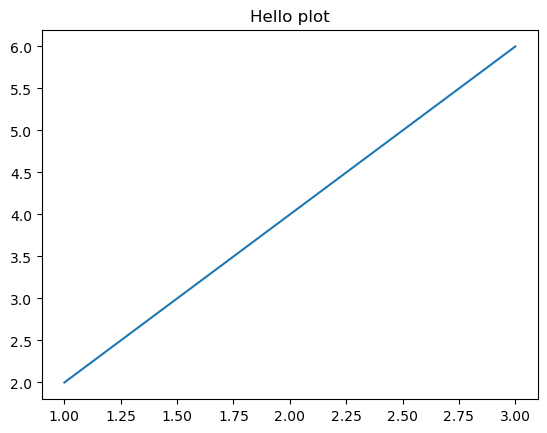

In [308]:
#pyplot 모율을 (관용적으로) plt라는 이름으로 import
import matplotlib.pyplot as plt
#x축 입력값 [1,2,3] y축 입력값 [2,4,6]으로 선 그래프 생성
plt.plot([1,2,3],[2,4,6])
plt.title('Hello plot')
plt.show()


## pyplot의 두 가지 중요 요소-Figure와 Axes
### Figure:객체를 그리기 위한 캔버스 역할
### Axes:실제 그림을 그리는 메서드를 가짐

#### plt.plot([1,2,3],[2,4,6]) :기본으로 설정된 axes에서 axes.plit함수 호출하고 이것은 다시 Line2D 객체 호출해 선 그래프 그림
#### plt.title() 내부적으로 Axes.set_title() 함수를 호출해 타이틀 설정

## Figure와 Axis의 사용



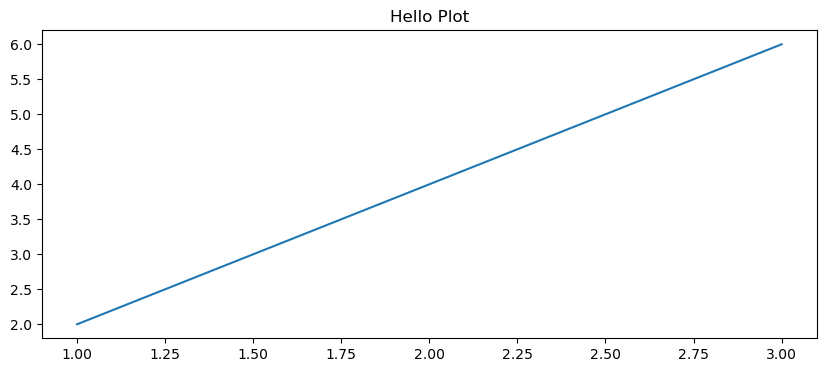

In [309]:
#plt.figure은 주로 figure 크기 조절에 사용
#아래는 figure 크기가 가로 10 세로 4인 Figure 객체 설정후 반환
plt.figure(figsize=(10,4))
plt.plot([1,2,3],[2,4,6])
plt.title('Hello Plot')
plt.show()



In [310]:
figure=plt.figure(figsize=(10,4))
print(type(figure))
#plt.figure가 많은 역할은 못하지만 노란색으로 배경색을 바꾸는 등은 할 수 있음

<class 'matplotlib.figure.Figure'>


<Figure size 1000x400 with 0 Axes>

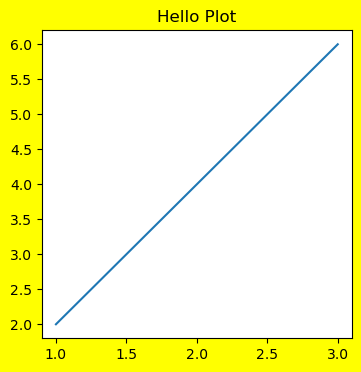

In [311]:
plt.figure(figsize=(4,4),facecolor='yellow')
plt.plot([1,2,3],[2,4,6])
plt.title('Hello Plot')
plt.show()

<class 'matplotlib.axes._axes.Axes'>


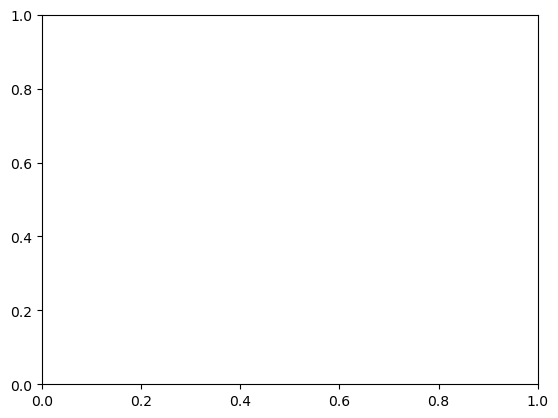

In [312]:
ax=plt.axes()
print(type(ax))

### plt.subplots(): Figure와 Axes 객체 함께 가져올 수 있다


fig,ax=plt.subplots()
print('fig type:',type(fig),'\nax type:',type(ax))

## Axes 객체로 바로 선 그래프 그리기

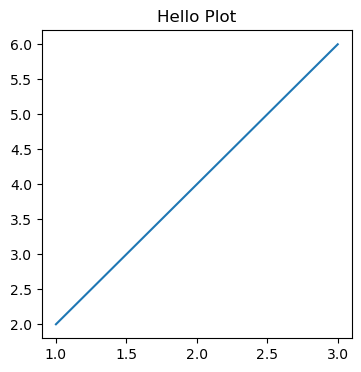

In [313]:
fig,ax=plt.subplots(figsize=(4,4))
ax.plot([1,2,3],[2,4,6])
ax.set_title("Hello Plot")
plt.show()

## 여러 개의 plot 가지는 subplot들 생성
#### subplot은 여러 개의 subplot 생성에 도와주고 일반적으로 개별 Figure마다 하나의 Axes를 가진다
#### 주요 인자: nrows,ncols,figsize
#### nrows:여러 개의 subplot의 행의 개수 ncols: 여러개의 subplot의 열의 개수
#### axes가 여러 개면 튜플 형태로 반환

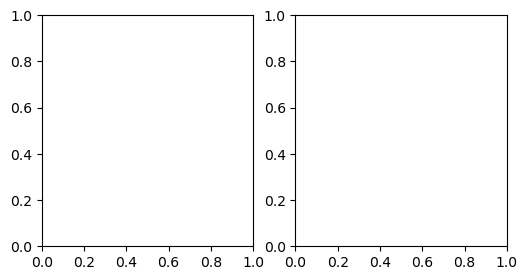

In [314]:
fig,(ax1,ax2)=plt.subplots(nrows=1,ncols=2,figsize=(6,3))

## pyplot의 plot 함수를 이용해 선 그래프 그리기

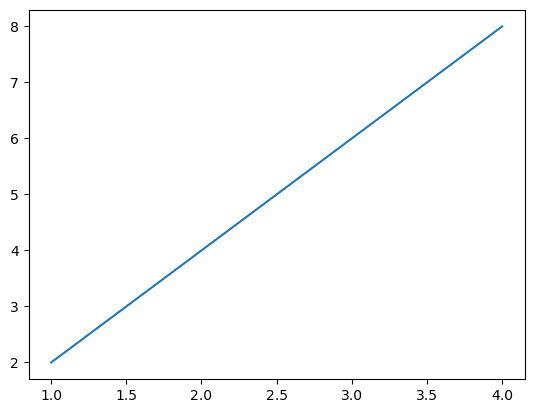

In [315]:
import numpy as np
import pandas as pd
x_value=[1,2,3,4]
y_value=[2,4,6,8]
plt.plot(x_value,y_value)
plt.show()

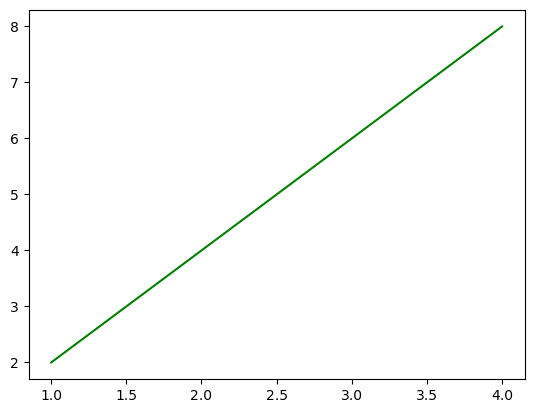

In [316]:
# color 인자를 green으로 설정하여 선의 색깔을 녹색으로 변경
plt.plot(x_value,y_value,color='green')


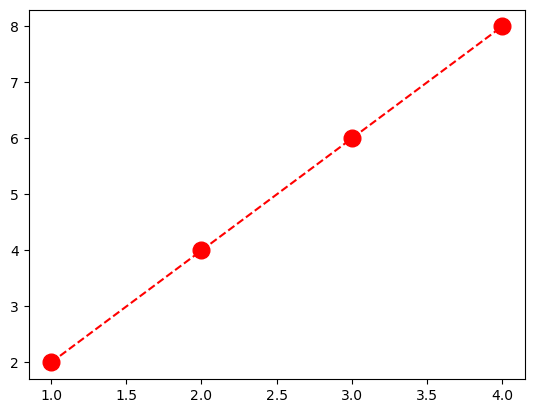

In [317]:
plt.plot(x_value,y_value,color='red',marker='o',linestyle='dashed',markersize=12)

## 축 명칭 설정, 축의 눈금(틱) 값 회전, 범례(legend) 설정하기

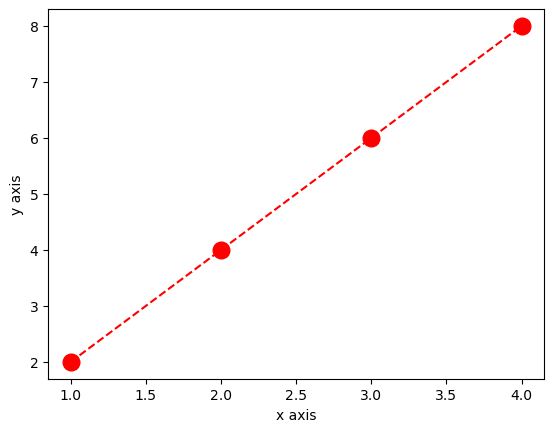

In [318]:
plt.plot(x_value,y_value,color='red',marker='o',linestyle='dashed',markersize=12)
plt.xlabel('x axis')
plt.ylabel('y axis')
plt.show()

### 틱값 회전

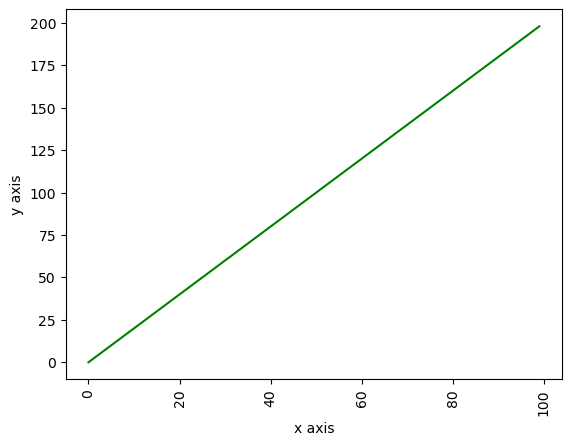

In [319]:
x_value=np.arange(0,100)
y_value=2*x_value
plt.plot(x_value,y_value,color='green')
plt.xlabel('x axis')
plt.ylabel('y axis')
plt.xticks(rotation=90)
plt.show()

### 맷플롯립은 축 값이 문자열인 경우는 모든 값을 나타내주지만 축 값이 수자값이면 축의 크기에 따라 간격 만든다. 세밀하게 하고 싶으면 ticks로 조정 가능

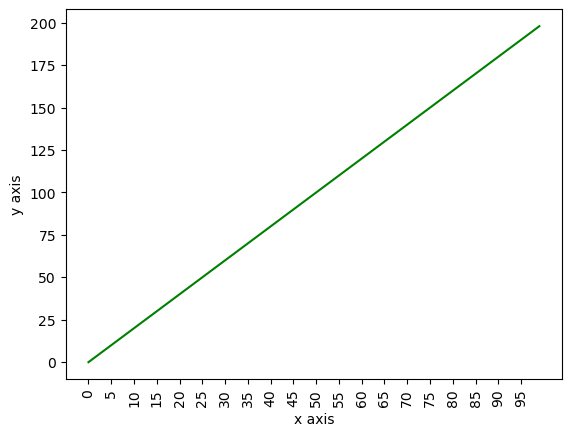

In [320]:
x_value=np.arange(0,100)
y_value=2*x_value
plt.plot(x_value,y_value,color='green')
plt.xlabel('x axis')
plt.ylabel('y axis')
plt.xticks(ticks=np.arange(0,100,5),rotation=90)
plt.show()

### 범례 설정
#### plt.plot 함수 내 label 인자 값을 이용해 플롯에 명칭을 부여하고 plt.legend 호출하고 범례 표시해야 함

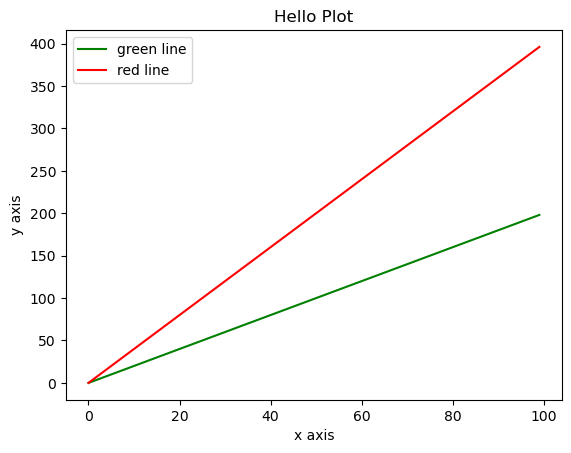

In [321]:
x_value01=np.arange(0,100)
y_value01=x_value01*2
y_value02=4*x_value01

plt.plot(x_value01,y_value01,color='green',label='green line')
plt.plot(x_value01,y_value02,color='red',label='red line')
plt.xlabel('x axis')
plt.ylabel('y axis')
plt.legend()
plt.title('Hello Plot')
plt.show()


#### 선과 막대그래프 같이 그리기

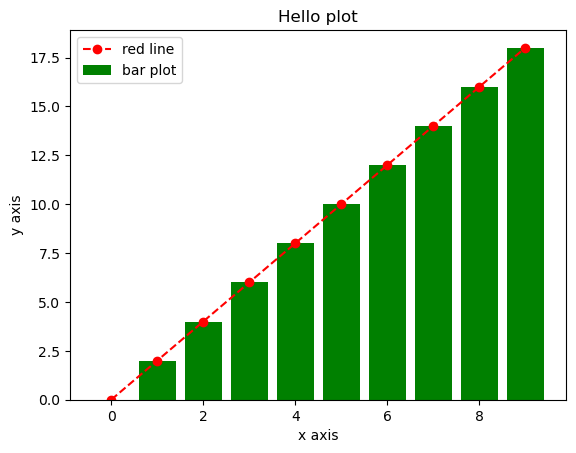

In [322]:
x_value01=np.arange(0,10)
y_value01=x_value01*2

#마커를 포함한 빨간색 대시 선 그래프와 label은 red line을 설정
plt.plot(x_value01,y_value01,color='red',marker='o',linestyle='dashed',label='red line')
#x값에 따른 y값을 나타내는 초록색 막대 그래프를 그리고 label은 bar plot으로 설정
plt.bar(x_value01,y_value01,color='green',label='bar plot')
plt.xlabel('x axis')
plt.ylabel('y axis')
plt.legend()
plt.title('Hello plot')
plt.show()

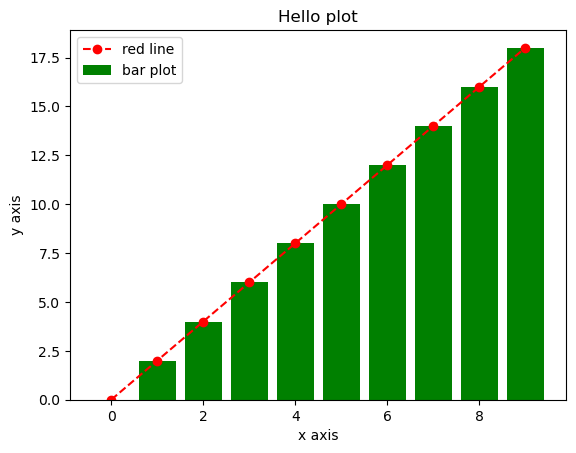

In [323]:
figure=plt.figure()
#Axes 객체를 추출하여 ax 변수에 할당
ax=plt.axes()
#plt.plot()은 ax.plot()으로 plt.bar()는 ax.bar()로 변경
ax.plot(x_value01,y_value01,color='red',marker='o',linestyle='dashed',label='red line')
ax.bar(x_value01,y_value01,color='green',label='bar plot')

ax.set_xlabel('x axis')
ax.set_ylabel('y axis')
ax.legend()
ax.set_title('Hello plot')
plt.show()

## 여러 개의 subplots들을 이용해 개별 그래프를 subplot별로 시각화 하기

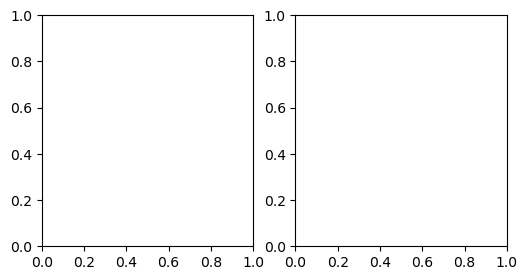

In [324]:
fig,ax=plt.subplots(nrows=1,ncols=2,figsize=(6,3))
#각각의 axes는 넘파이 ndarray로 값을 가짐

In [325]:
print('ax type:',type(ax))
print('ax[0] type:',type(ax[0]))
print('ax[1] type:',type(ax[1]))

ax type: <class 'numpy.ndarray'>
ax[0] type: <class 'matplotlib.axes._axes.Axes'>
ax[1] type: <class 'matplotlib.axes._axes.Axes'>


#### 여러개의 axes의 경우 axes 단위로 다뤄야 함

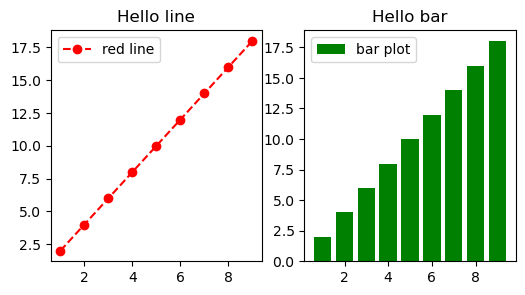

In [326]:
import numpy as np
x_value01=np.arange(1,10)
x_value02=np.arange(1,20)
y_value01=2*x_value01
y_value02=2*x_value02

fig,ax=plt.subplots(nrows=1,ncols=2,figsize=(6,3))

#개별 Axes 객체들을 각각 이용해 선 그래프와 막대 그래프를 그림

ax[0].plot(x_value01,y_value01,color='red',marker='o',linestyle='dashed',label='red line')
ax[1].bar(x_value01,y_value01,color='green',label='bar plot')
ax[0].legend()
ax[1].legend()

#개별 Axes 객체 각각에 타이틀을 설정
ax[0].set_title('Hello line')
ax[1].set_title('Hello bar')
plt.show()


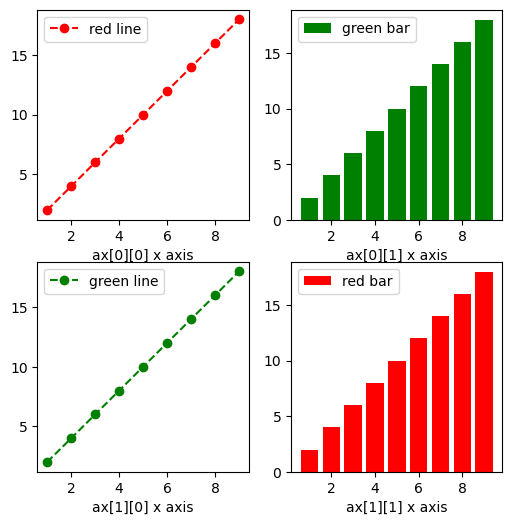

In [327]:
import numpy as np
x_value01=np.arange(1,10)
x_value02=np.arange(1,20)
y_value01=2*x_value01
y_value02=2*x_value02

#figsize는 (6,6)인 Figure와 2X2개의 Axes를 가지는 subplots을 반환
fig,ax=plt.subplots(nrows=2,ncols=2,figsize=(6,6))
ax[0][0].plot(x_value01,y_value01,color='red',marker='o',linestyle='dashed',label='red line')
ax[0][1].bar(x_value01,y_value01,color='green',label='green bar')
ax[1][0].plot(x_value01,y_value01,color='green',marker='o',linestyle='dashed',label='green line')
ax[1][1].bar(x_value01,y_value01,color='red',label='red bar')

ax[0][0].set_xlabel('ax[0][0] x axis')
ax[0][1].set_xlabel('ax[0][1] x axis')
ax[1][0].set_xlabel('ax[1][0] x axis')
ax[1][1].set_xlabel('ax[1][1] x axis')

ax[0][0].legend()
ax[0][1].legend()
ax[1][0].legend()
ax[1][1].legend()

plt.show()

# 시본(Seaborn)

## 시각화를 위한 차트 / 그래프 유형

#### :히스토그램, 바 플롯, 박스 플롯, 바이올린 플롯, 스캐터 플롯, 상관 히트맵

#### 바플롯: 특정 칼럼의 이산 값 기준 다른 칼럼의 연속형 값을 막대 그래프로 시각화
#### 히스토그램, 바이올린 플롯: 연석형 데이터의 분포가 정규 분포인지 왜곡되어 있는지 시각화
#### 박스 플롯: 연속형 데이터 분위 시각화
#### 스캐터 플롯 2개의 연속형 칼럼들에 대한 분포 및 관계를 시각화
#### 상관 히트맵: 다수의 연속형 칼럼들의 상관 관계를 온도를 나타내는 시각적 컬러 기반으로 표현


## 히스토그램
### histplot() axes 레벨 함수, displot() Figure레벨 함수
#### :통계적 분석과 분표도 파악에 좋음 시본 이외에도 판다스 맷플롯립에서도 제공
#### bins는 구간의 개수이다 kde=True를 하면 연속 확률 분포 곡선도 그려준다

In [328]:
import pandas as pd
titanic_df=pd.read_csv('train.csv')
titanic_df.head(5)

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr....",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mr...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, ...",female,26.0,0,0,STON/O2. 31...,7.9250,NaN,S
3,4,1,1,"Futrelle, M...",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. ...",male,35.0,0,0,373450,8.0500,NaN,S


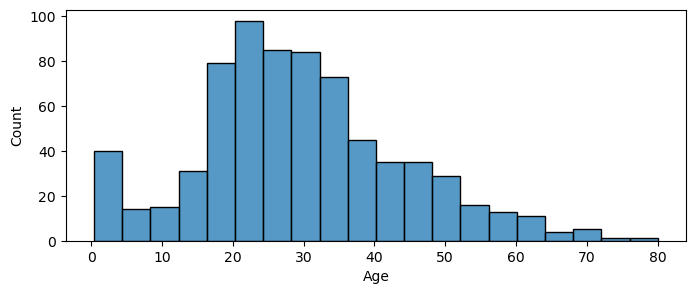

In [329]:
import matplotlib.pyplot as plt
import seaborn as sns
plt.figure(figsize=(8,3))
sns.histplot(titanic_df['Age'],bins=20)
plt.show()

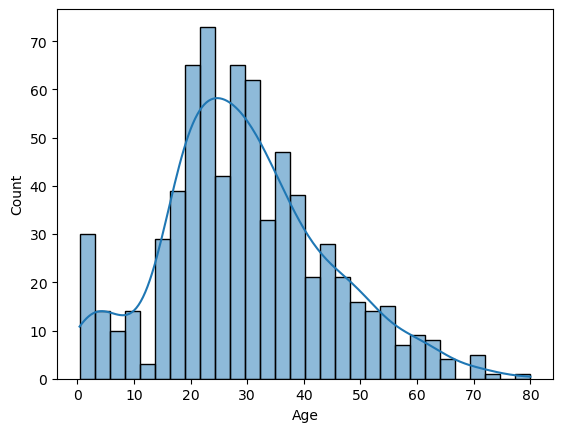

In [330]:
sns.histplot(x='Age',data=titanic_df,bins=30,kde=True)
plt.show()

<Figure size 800x400 with 0 Axes>

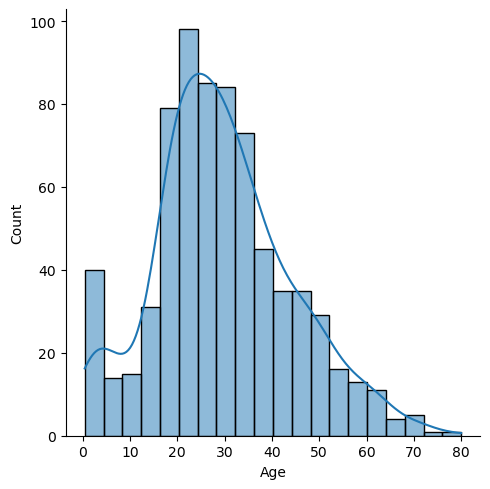

In [331]:
import seaborn as sns

#seaborn의 figure레벨 그래프는 plt.figure의 크기를 조절할 수 ㅓㅂㅅ다.
plt.figure(figsize=(8,4))
sns.displot(x='Age',data=titanic_df,kde=True)
plt.show()

#### displot 함수에서 height와 aspect 값으로 크기 조절

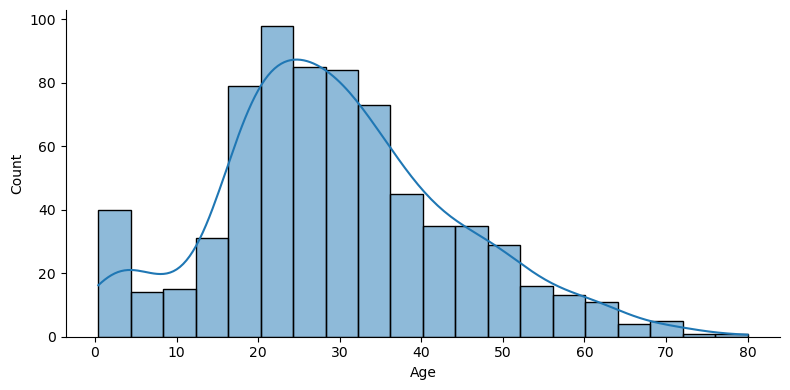

In [332]:
import seaborn as sns
sns.displot(titanic_df['Age'],kde=True,height=4,aspect=2)
plt.show()

## 카운트 플롯

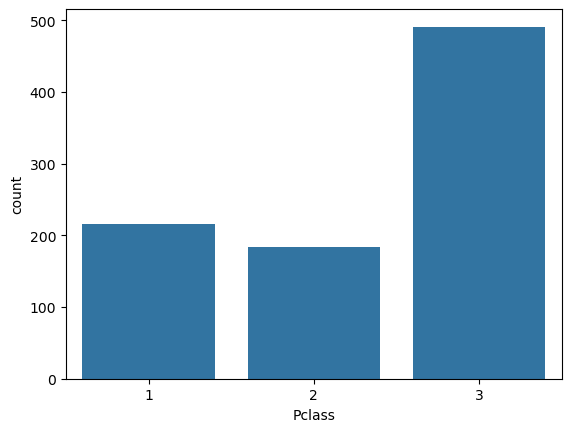

In [333]:
sns.countplot(x='Pclass',data=titanic_df)
plt.show()

## 바 플롯

#### : 주로 X에는 이산형 값을 Y에는 연속형 값을 사용

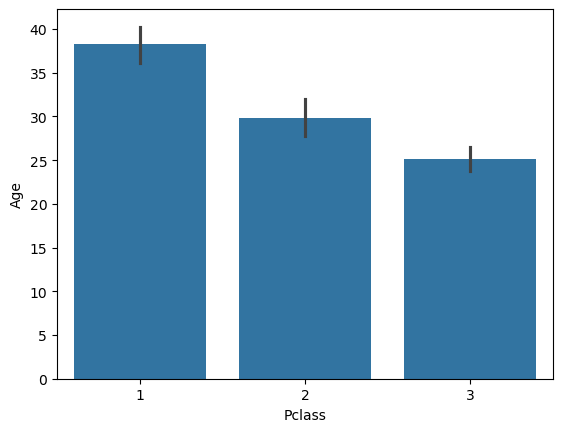

In [334]:
sns.barplot(x='Pclass',y='Age',data=titanic_df)
plt.show()

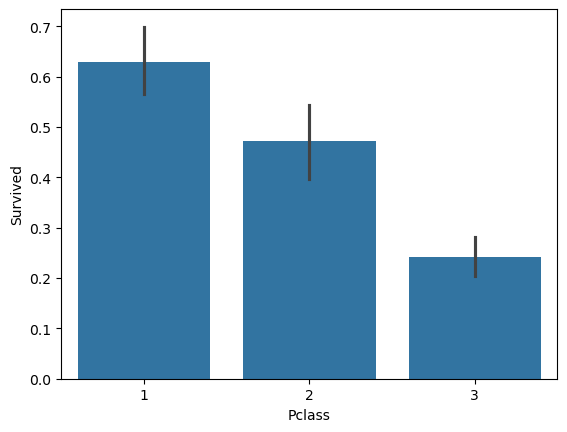

In [335]:
sns.barplot(x='Pclass',y='Survived',data=titanic_df)
plt.show()

#### survived 값은 연속형이 아니고 이산형 데이터지만 0과 1로 되어 있기에 평균 비율로 나타낼 수 있다
#### 데이터 유형을 반영해 수평 막대 그래프로 만들어주거나 수직 막대 그래프로 만들어준다.

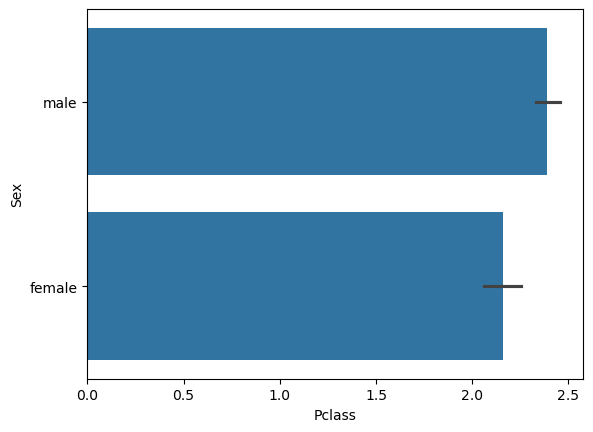

In [336]:
sns.barplot(x='Pclass',y='Sex',data=titanic_df)
plt.show()

<Axes: xlabel='Name', ylabel='Sex'>

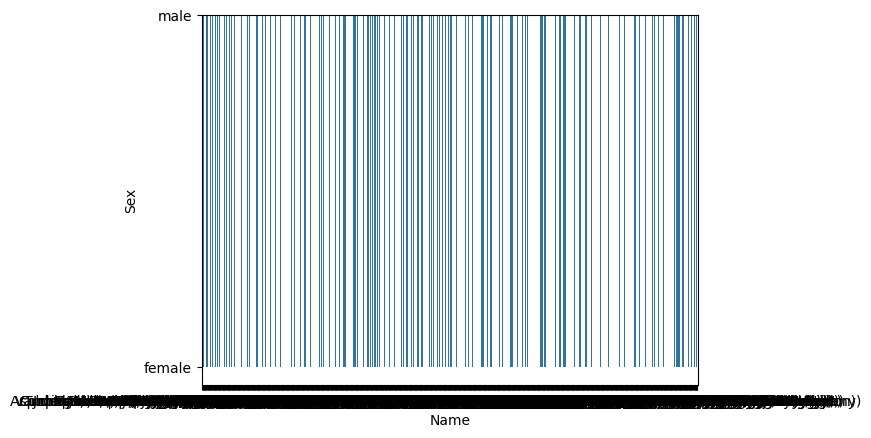

In [337]:
#x 인자로 문자열인 Name을 y 인자로 문자열인 Sex를 입력하므로 barplot은 오류를 발생
sns.barplot(x='Name',y='Sex',data=titanic_df)

#### 보통 이산형 데이터가 들어가면 평균 값으로 나오지만 estimator 인자로 변경할 수 있음

/var/folders/lw/typ49f210hb_6wlv9djt899c0000gn/T/ipykernel_1368/1073465639.py:2: FutureWarning: 

The `ci` parameter is deprecated. Use `errorbar=None` for the same effect.

  sns.barplot(x='Pclass',y='Survived',data=titanic_df,ci=None,estimator=sum)


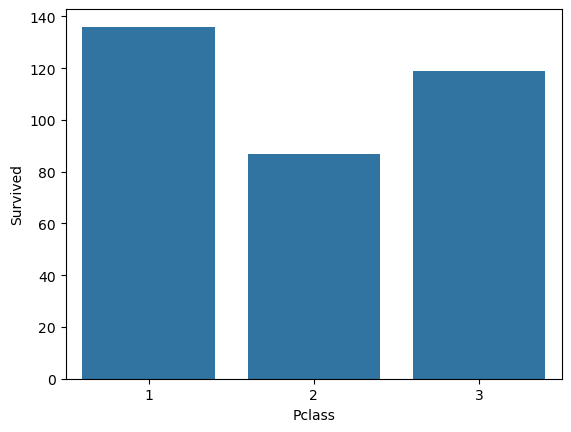

In [338]:
#estimator=sum을 적용하여 평균이 아닌 총합으로 표현
sns.barplot(x='Pclass',y='Survived',data=titanic_df,ci=None,estimator=sum)
plt.show()

## barplot() 함수의 hue 인자를사용해 시각화 정보를 추가적으로 세분화하기

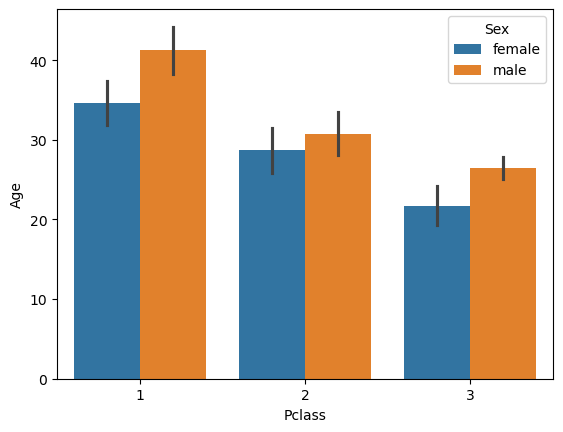

In [339]:
#아래는 Pclass ㅌcnrdlau hue 값으로 Secfh 설정
#개별 Pclass 값별 Sex에 따른 Age 평균 값을 구삼
sns.barplot(x='Pclass',y='Age',hue='Sex',data=titanic_df)
plt.show()

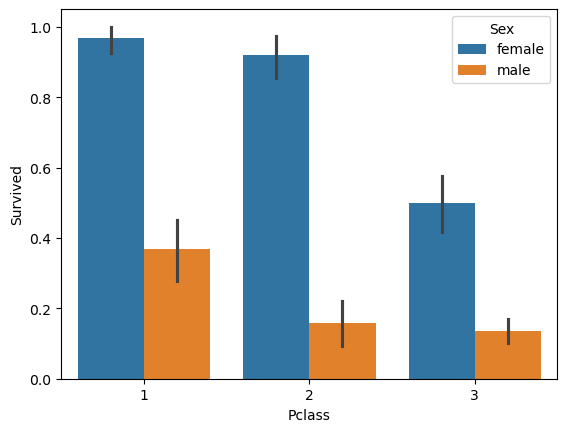

In [340]:
sns.barplot(x='Pclass',y='Survived',hue='Sex',data=titanic_df)
plt.show()

## 박스플롯

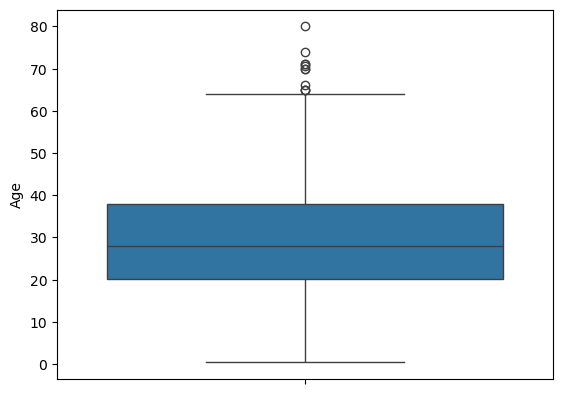

In [341]:
sns.boxplot(y='Age',data=titanic_df)
plt.show()

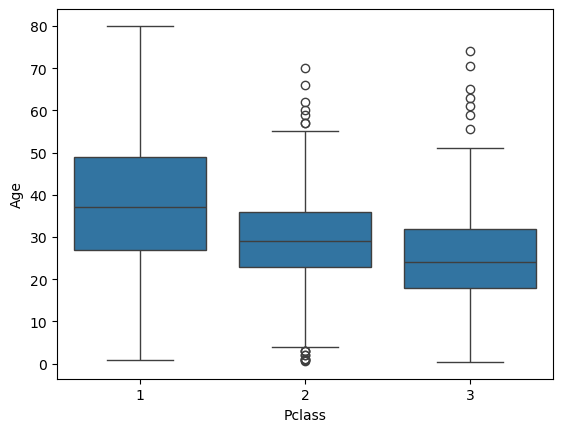

In [342]:
sns.boxplot(x='Pclass',y='Age',data=titanic_df)
plt.show()

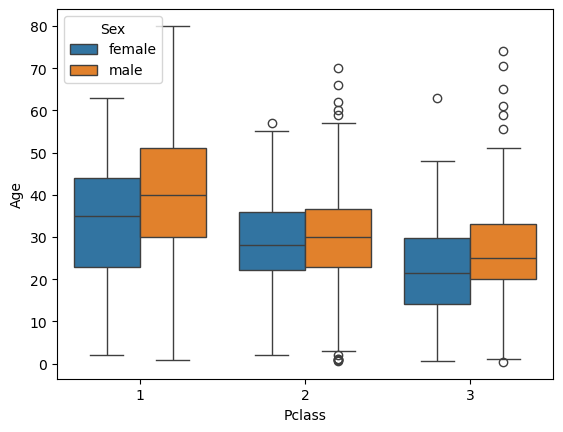

In [343]:
sns.boxplot(x='Pclass',y='Age',hue='Sex',data=titanic_df)
plt.show()

## 바이올린 플롯
#### :연속 확률 분포 곡선과 박스 플롯을 함께 시각화가 가능
#### violinplot() 사용


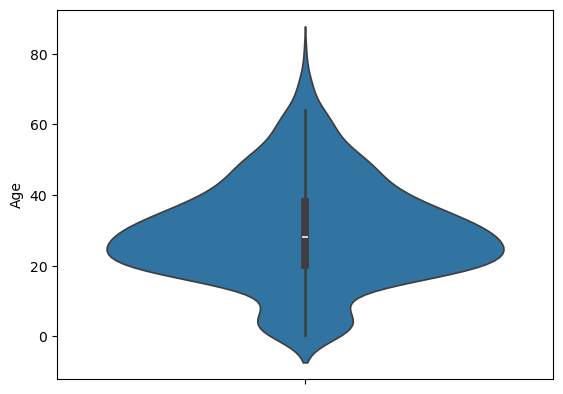

In [344]:
sns.violinplot(y='Age',data=titanic_df)
plt.show()

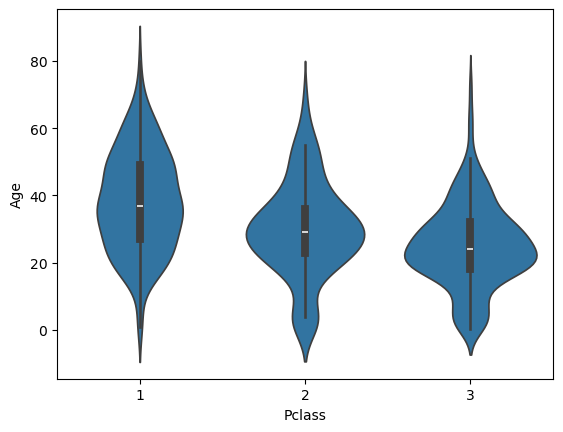

In [345]:
#x 축값인 Pclass의 값별로 y축 값인 Age의 바이올린 플룻 그림을 그림
sns.violinplot(x='Pclass',y='Age',data=titanic_df)
plt.show()


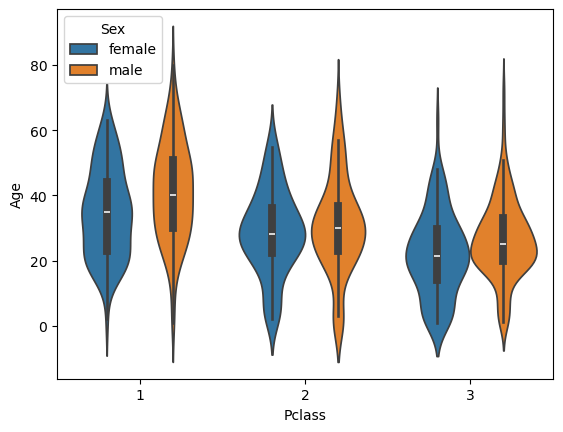

In [346]:
sns.violinplot(x='Pclass',y='Age',hue='Sex',data=titanic_df)
plt.show()


## subplot를 이용하여 시본의 다양한 그래프를 시각화

index: 0
index: 1
index: 2


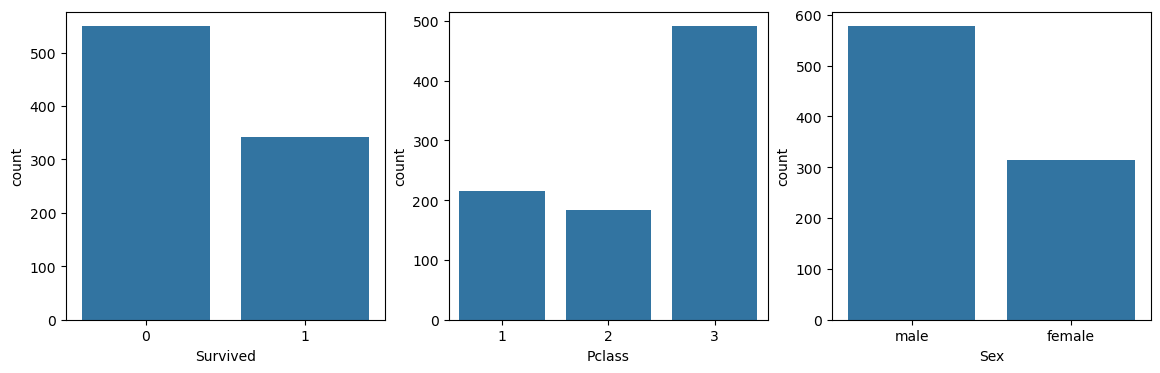

In [347]:
cat_columns=['Survived','Pclass','Sex']
#nrows는 1이고 ncolumn의 개수 만큼인 subplotsdmf tjfwjd
fig,axs=plt.subplots(nrows=1,ncols=len(cat_columns),figsize=(14,4))
for index,column in enumerate(cat_columns):
    print('index:',index)
    sns.countplot(x=column,data=titanic_df,ax=axs[index])

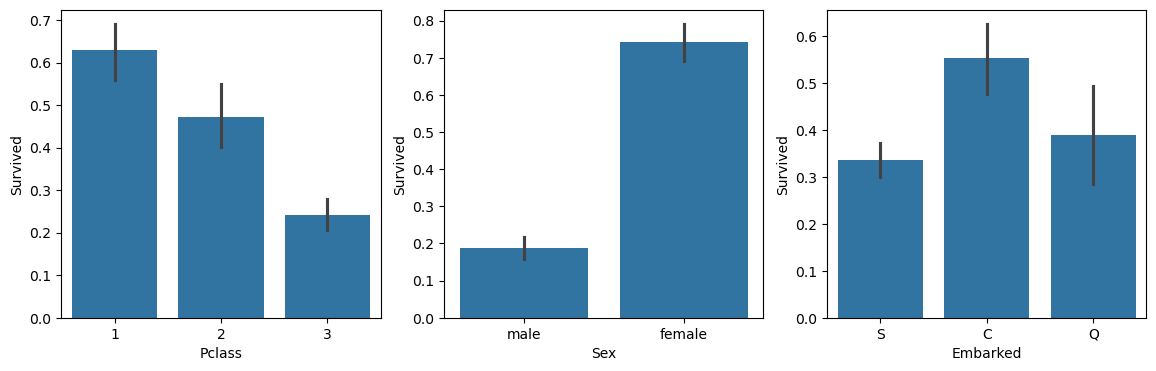

In [348]:
cat_columns=['Pclass','Sex','Embarked']
fig,axs=plt.subplots(nrows=1,ncols=len(cat_columns),figsize=(14,4))
for index,column in enumerate(cat_columns):
    sns.barplot(x=column,y='Survived',data=titanic_df,ax=axs[index])

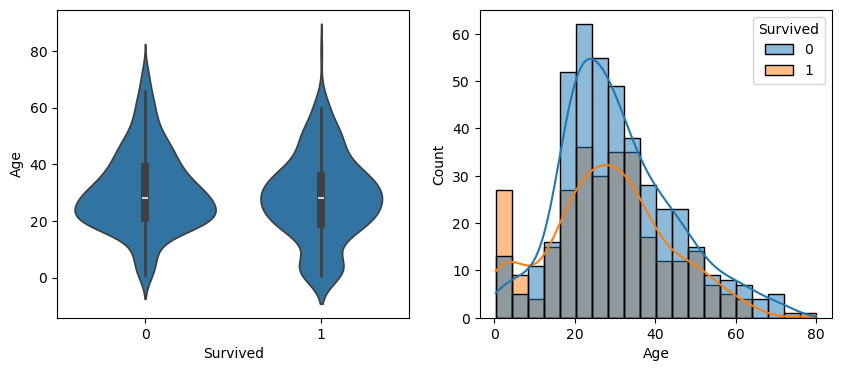

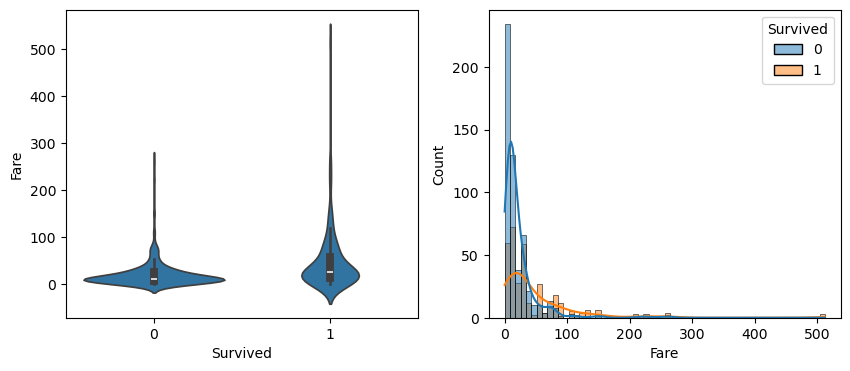

In [349]:
cont_columns=['Age','Fare']
for column in cont_columns:
    fig,axs=plt.subplots(nrows=1,ncols=len(cont_columns),figsize=(10,4))
    sns.violinplot(x='Survived',y=column,data=titanic_df,ax=axs[0])
    sns.histplot(x=column,data=titanic_df,kde=True,hue='Survived',ax=axs[1])

## 산점도 스캐터 플롯(Scatter Plot)
#### 좌표 상에 점을 찍어 변수 간의 상관관계를 확인 / x축과 y축 모두 연속형 숫자값을 넣음

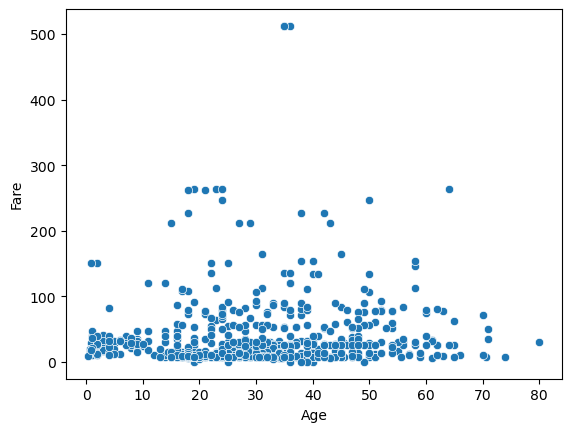

In [350]:
sns.scatterplot(x='Age',y='Fare',data=titanic_df)
plt.show()

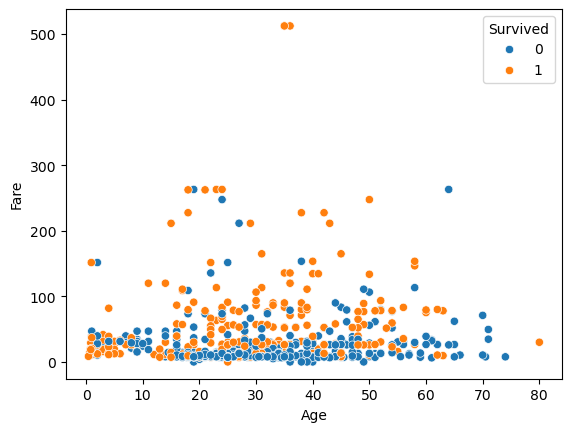

In [351]:
sns.scatterplot(x='Age',y='Fare',hue='Survived',data=titanic_df)
plt.show()

#### style인자로 추가 정보 제공 가능

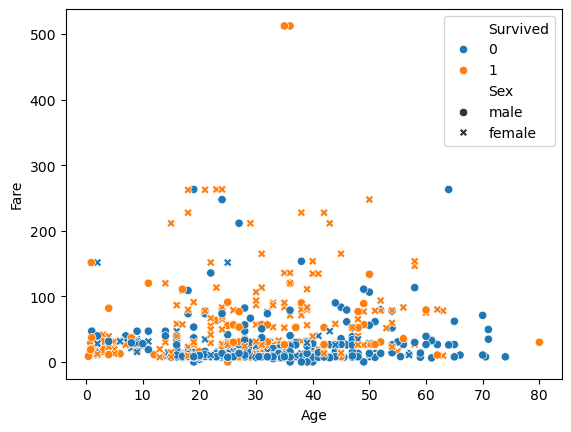

In [352]:
sns.scatterplot(x='Age',y='Fare',hue='Survived',style='Sex',data=titanic_df)
plt.show()

## 상관 히트맵
#### :다수의 속성들 간의 상관계수를 히트맵 형태로 나타낼 수 있다. 열을 의미하는(heat)와 지도를 의미하는 맵(map)이 결합
#### 상관계수: 두 속성(변수/ 칼럼/ 피처)들 간의 선형적인 연관 관계를 수치화한 값
#### ->> 두 속성이 상관없으면 0 같은 방향으로 완전히 동일하면 1 반대 방향으로 완전히 동일하면 -1
### 0으로 가까울 수록 빨간색 1에 갈 수록 밝음
### 주요 인자들: annot:상관계수값 표현 cbar 옆에 막대 생성, cmap:색깔 설정

In [354]:
corr_df=titanic_df.corr(numeric_only=True)
corr_df

,PassengerId,Survived,Pclass,Age,SibSp,Parch,Fare
PassengerId,1.000000,-0.005007,-0.035144,0.036847,-0.057527,-0.001652,0.012658
Survived,-0.005007,1.000000,-0.338481,-0.077221,-0.035322,0.081629,0.257307
Pclass,-0.035144,-0.338481,1.000000,-0.369226,0.083081,0.018443,-0.549500
Age,0.036847,-0.077221,-0.369226,1.000000,-0.308247,-0.189119,0.096067
SibSp,-0.057527,-0.035322,0.083081,-0.308247,1.000000,0.414838,0.159651
Parch,-0.001652,0.081629,0.018443,-0.189119,0.414838,1.000000,0.216225
Fare,0.012658,0.257307,-0.549500,0.096067,0.159651,0.216225,1.000000


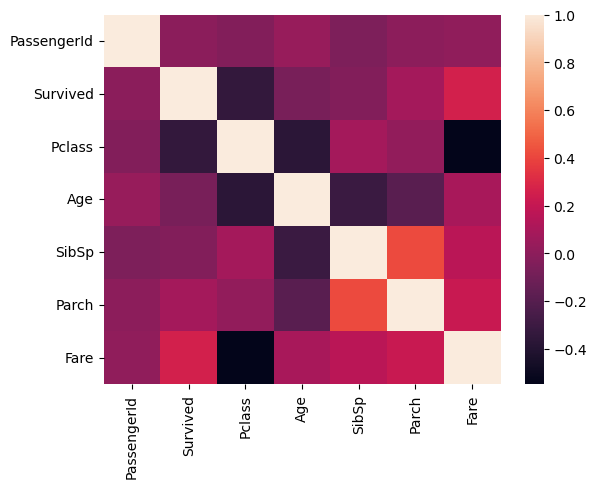

In [356]:
#상관계수를 DataFrame으로 구하고 이를 heatmap()dml dlswkfh dlqfur
corr=titanic_df.corr(numeric_only=True)
sns.heatmap(corr)
plt.show()

In [ ]:
sns.heatmap(corr,annot=True,fmt='.1f',cbar=True)
plt.show()